In [1]:
# Módulos para lidar com arquivos
import os
import glob
import shutil

# Pacote para DataFrame e Plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de nlp
import re
import nltk
import spacy

# Pacotes de nlp e IA
from sklearn.feature_extraction.text import CountVectorizer


In [2]:
# Carregando recursos
nltk.download('stopwords',quiet=True)
nltk.download('punkt', quiet=True)
stop_words_pt = nltk.corpus.stopwords.words('portuguese')

try:
    nlp = spacy.load('pt_core_news_sm')
except OSError:
    print("Modelo spacy não encontrado. Execute !python -m spacy download pt_core_news_sm")
    nlp = None

In [3]:
# Definição das pastas de entrada e saída
PASTA_ENTRADA = 'processos'
PASTA_SAIDA = 'PII_anonimizados'

# Limpar e recriar a pasta de saída
if os.path.exists(PASTA_SAIDA):
    shutil.rmtree(PASTA_SAIDA)
os.makedirs(PASTA_SAIDA)

## Exploração de dados

In [6]:
# Carregar todo o corpus de texto em memória
corpus_total = []
nomes_arquivos = []

arquivos_analise = glob.glob(os.path.join(PASTA_ENTRADA,'*.txt'))

for caminho in arquivos_analise:

    with open(caminho, 'r', encoding='UTF-8') as f:
        corpus_total.append(f.read())
        nomes_arquivos.append(os.path.basename(caminho))

print(f"Total de arquivos carregados: {len(corpus_total)}")
    

Total de arquivos carregados: 10


In [7]:
corpus_total

['EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO DA 10ª VARA CÍVEL DA COMARCA DE MANAUS - AM.\n\nProcesso nº: 0001234-99.2023.8.04.0001\nAUTOR: Beatriz Helena Cardoso, brasileira, casada, portadora do CPF nº 012.345.678-99, residente na Avenida Eduardo Ribeiro, 670, contato pelo email beatriz.cardoso@email.com.\nRÉU: Eletrodomésticos Casa Feliz S.A., pessoa jurídica de direito privado. \n\nAÇÃO DE SUBSTITUIÇÃO DE PRODUTO C/C INDENIZAÇÃO\n\nVem respeitosamente à presença de Vossa Excelência propor a presente ação, com fundamento no Código de Defesa do Consumidor. \n\nDOS FATOS \nNo dia 08/12/2023, a Autora adquiriu geladeira que apresentou defeito no prazo de garantia. A Autora acionou a assistência técnica por três vezes, sem resolução do problema.\n\nO valor do produto foi de R$ 4.200,00. Além disso, requer indenização por danos morais no valor de R$ 3.000,00.\n\nDOS PEDIDOS\nDiante do exposto, requer a substituição do produto ou restituição, além de R$ 3.000,00 por danos morais.\n\nNes

In [8]:
# Vetorização Inicial
vec_analise = CountVectorizer(stop_words=stop_words_pt,min_df=1)
X_analise = vec_analise.fit_transform(corpus_total)
print(f"Shape da matriz de frequência: {X_analise.shape}")

Shape da matriz de frequência: (10, 427)


In [9]:
vec_analise.vocabulary_.items()

dict_items([('excelentíssimo', 237), ('senhor', 388), ('doutor', 221), ('juiz', 275), ('direito', 214), ('10ª', 26), ('vara', 417), ('cível', 197), ('comarca', 172), ('manaus', 289), ('am', 121), ('processo', 348), ('nº', 311), ('0001234', 3), ('99', 101), ('2023', 44), ('04', 18), ('0001', 2), ('autor', 139), ('beatriz', 145), ('helena', 256), ('cardoso', 157), ('brasileira', 151), ('casada', 160), ('portadora', 337), ('cpf', 194), ('012', 16), ('345', 61), ('678', 83), ('residente', 366), ('avenida', 141), ('eduardo', 224), ('ribeiro', 373), ('670', 82), ('contato', 184), ('email', 228), ('réu', 381), ('eletrodomésticos', 225), ('casa', 159), ('feliz', 243), ('pessoa', 332), ('jurídica', 281), ('privado', 345), ('ação', 142), ('substituição', 402), ('produto', 349), ('indenização', 265), ('vem', 418), ('respeitosamente', 368), ('presença', 343), ('vossa', 424), ('excelência', 238), ('propor', 350), ('presente', 342), ('fundamento', 250), ('código', 198), ('defesa', 205), ('consumidor

In [11]:
# Somar frequências Globais
soma_palavras = X_analise.sum(axis=0)
soma_palavras

matrix([[27,  8,  8,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          3,  1,  2,  4,  2,  2,  1,  3,  2,  3,  1,  4,  1,  1,  1,  5,
          1,  2,  1,  4,  3,  2,  1,  4,  1,  1,  2,  1, 21,  9,  1,  1,
          4,  1,  3,  1,  1,  2,  1,  2,  1,  1,  2,  1,  2,  3,  1,  1,
          1,  1,  2,  2,  1,  2,  2,  1,  1,  2,  1,  2,  3,  1,  1,  2,
          1,  2,  1,  3,  1,  1,  1,  2,  2,  2,  1,  1,  4,  3,  4,  1,
          1,  1,  3,  1,  1,  2,  1,  1,  1,  2,  1,  1,  1,  1,  1,  1,
          2,  5,  5,  1,  1,  2,  1,  1, 12,  2,  1,  2,  1,  1,  2,  1,
          1,  1,  1,  1,  1,  2,  1,  1,  1,  1,  1, 20, 10,  4, 20,  2,
          1,  2,  1,  1,  2,  1,  1,  5,  6,  2,  1,  1,  2,  2,  2,  2,
          2,  1,  2,  1,  1,  3,  1,  1,  1,  2,  1,  1, 10,  1,  2,  8,
          1,  1,  1,  1,  1,  1, 10,  2, 10,  1,  1,  1,  2,  6,  1,  2,
          1,  2, 10,  2,  1, 10, 13,  1, 12,  1,  2,  1, 10, 10,  1,  1,
          1,  3,  1,  2, 10, 10, 21, 10,  1,  1,  2

In [12]:
palavras_freq = [(word, soma_palavras[0, idx]) for word, idx in vec_analise.vocabulary_.items()]

In [14]:
palavras_freq

[('excelentíssimo', np.int64(10)),
 ('senhor', np.int64(10)),
 ('doutor', np.int64(10)),
 ('juiz', np.int64(10)),
 ('direito', np.int64(21)),
 ('10ª', np.int64(1)),
 ('vara', np.int64(10)),
 ('cível', np.int64(10)),
 ('comarca', np.int64(10)),
 ('manaus', np.int64(2)),
 ('am', np.int64(2)),
 ('processo', np.int64(10)),
 ('nº', np.int64(22)),
 ('0001234', np.int64(1)),
 ('99', np.int64(2)),
 ('2023', np.int64(21)),
 ('04', np.int64(2)),
 ('0001', np.int64(8)),
 ('autor', np.int64(20)),
 ('beatriz', np.int64(2)),
 ('helena', np.int64(1)),
 ('cardoso', np.int64(2)),
 ('brasileira', np.int64(5)),
 ('casada', np.int64(2)),
 ('portadora', np.int64(5)),
 ('cpf', np.int64(10)),
 ('012', np.int64(3)),
 ('345', np.int64(3)),
 ('678', np.int64(3)),
 ('residente', np.int64(10)),
 ('avenida', np.int64(4)),
 ('eduardo', np.int64(2)),
 ('ribeiro', np.int64(1)),
 ('670', np.int64(1)),
 ('contato', np.int64(10)),
 ('email', np.int64(20)),
 ('réu', np.int64(12)),
 ('eletrodomésticos', np.int64(1)),
 ('c

In [13]:
# Criar DataFrame
df_freq_global = pd.DataFrame(palavras_freq, columns=['Termo', 'Frequência'])
df_freq_global = df_freq_global.sort_values(by='Frequência', ascending=False)


In [17]:
# Mostrar tabela de frequência
df_freq_global.head()

,Termo,Frequência
78,00,27
12,nº,22
15,2023,21
4,direito,21
43,ação,20


/tmp/ipykernel_3321/1502849628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freq_global.head(30), x='Frequência', y='Termo', palette='viridis')


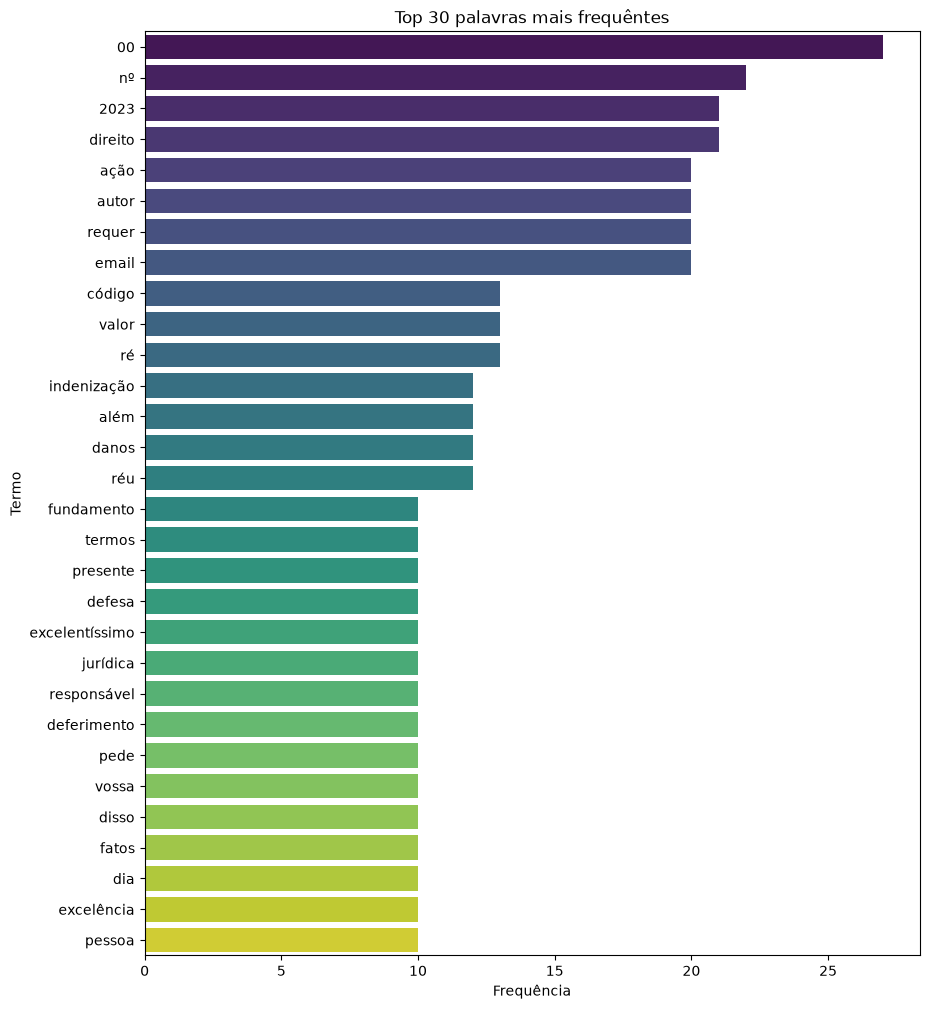

In [19]:
# Mostrar um plot 
plt.figure(figsize=(10,12))
sns.barplot(data=df_freq_global.head(30), x='Frequência', y='Termo', palette='viridis')
plt.title('Top 30 palavras mais frequêntes')
plt.show()

In [20]:
# Criar uma lista de stop words "jurídicas"

stopwords_juridicas = []
TOP_N = 30

for palavra, freq in palavras_freq:
    if not palavra.isdigit():
        stopwords_juridicas.append(palavra)
    if len(stopwords_juridicas) >= TOP_N:
        break

In [21]:
stopwords_juridicas

['excelentíssimo',
 'senhor',
 'doutor',
 'juiz',
 'direito',
 '10ª',
 'vara',
 'cível',
 'comarca',
 'manaus',
 'am',
 'processo',
 'nº',
 'autor',
 'beatriz',
 'helena',
 'cardoso',
 'brasileira',
 'casada',
 'portadora',
 'cpf',
 'residente',
 'avenida',
 'eduardo',
 'ribeiro',
 'contato',
 'email',
 'réu',
 'eletrodomésticos',
 'casa']

In [22]:
# Criar lista consolidando stop words
stop_words_juridico = stop_words_pt + stopwords_juridicas

In [23]:
len(stop_words_juridico)

237

## Criação das tarefas

In [24]:
# Extrair entidades usando RegEX
def extrair_entidades(texto):
    dados = {
        'CPFs': [],
        'Emails':[],
        'Datas':[],
        'Valores (R$)': [],
        'Legislação': []
    }

    # Extrair CPFs
    dados['CPFs'] = re.findall(r'\d{3}\.\d{3}\.\d{3}-\d{2}', texto)

    # Extrair Emails 
    dados['Emails'] = re.findall(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', texto)

    # Extrair Datas
    datas_simples = re.findall(r'\d{2}/\d{2}/\d{4}', texto)
    dados['Datas'].extend(datas_simples)

    # Extrair Valores
    dados['Valores'] = re.findall(r'(?<=R\$\s)[\d.,]+', texto)

    # Extrair Legislação
    dados['Legislação'] = re.findall(r'Lei nº? \d+(?:\.\d+)?', texto, flags=re.IGNORECASE)

    return dados

In [25]:
# Identificar tema do processo
def identificar_tema(texto):
    pattern = r'(?<=DOS FATOS)([\s\S]*?)(?=O valor|R\$|DOS PEDIDOS)'
    match = re.search(pattern, texto, flags=re.IGNORECASE)
    if not match:
        return "Seção DOS FATOS não foi encontrada"

    texto_fatos = match.group(0).strip()

    # Limpeza básica
    texto_limpo = re.sub(r'[^\w\s]', '', texto_fatos.lower())
    texto_limpo = re.sub(r'\d+', '', texto_limpo)
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo).strip()

    vectorizer = CountVectorizer(
        stop_words=stop_words_juridico,
        ngram_range=(1, 2),
        max_features=15
    )

    try:
        X = vectorizer.fit_transform([texto_limpo])
        vocab = vectorizer.get_feature_names_out()
        contagens = X.toarray().sum(axis=0)

        df_freq = pd.DataFrame({'termo': vocab, 'freq': contagens}).sort_values(by='freq', ascending=False)
        
        return ",".join(df_freq['termo'].head(3).tolist())
    except Exception:
        return "Conteúdo insuficiente para análise"

In [26]:
# Anomimizar Texto
def anomimizar_texto(texto):

    # Regex para CPF e E-Mails
    txt = re.sub(r'\d{3}\.\d{3}\.\d{3}-\d{2}', '[CPF]', texto)
    txt = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '[EMAIL]', txt)

    # NER (Named Entity Recognition) - Spacy
    if nlp:
        doc = nlp(txt)
        for ent in reversed(doc.ents):
            if ent.label_ == 'PER':
                txt = txt[:ent.start_char] + '[PESSOA]' + txt[ent.end_char:]
            if ent.label_ == 'ORG':
                txt = txt[:ent.start_char] + '[EMPRESA]' + txt[ent.end_char:]

    return txt